In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
import h5py
from robustpade import pade_approx

In [2]:
def Z_atomic(U:float,beta:float,mu:float):
    return 1+ 2*np.exp(beta*mu) + np.exp(-beta*(U-2*mu))

def Omega2_exact(U:float, beta:float, mu:float):
    
    Zat = Z_atomic(U, beta, mu)

    fact = np.exp(beta*mu)/Zat**2
    A = beta**2/2*(1+np.exp(-beta*(U-2*mu)))
    B = 2*beta/U*np.exp(-beta*(U/2-mu))*np.sinh(beta*U/2)
    return 2*fact*(A+B) #factor 2 for spin and 2 for sites!

#exact dimer partition function
Eplus = lambda t,U: U/2 + np.sqrt(U**2/4 + 4*t**2)
Eminus = lambda t,U: U/2 - np.sqrt(U**2/4 + 4*t**2)
def Z(t:float,U:float,beta:float,mu:float):

    A = 1 + 2*np.exp(-beta*(-t-mu)) + 2*np.exp(-beta*(t-mu)) + 3*np.exp(2*beta*mu) + np.exp(-beta*(U-2*mu))
    B = np.exp(-beta*(Eplus(t,U)-2*mu)) + np.exp(-beta*(Eminus(t,U)-2*mu))
    C = 2*np.exp(-beta*(U+t-3*mu)) +2*np.exp(-beta*(U-t-3*mu)) + np.exp(-2*beta*U + 4 * beta * mu) 

    return A+B+C


#exact dimer thermodynamic potential -betalnZ/2
def logZ(t:float,U:float,beta:float,mu:float):
    return -1.0/2*np.log(Z(t,U,beta,mu)) #free energy per site

U = 6.0
beta = 2.0

In [3]:
path = '/Users/louissharma/Desktop/results_sc/results/final_results.h5'
with h5py.File(path, 'r') as f:
    mus = f['mu_list'][:]
    means = f['mean_list'][:]
    errors = f['error_list'][:]


In [4]:
a0s = -np.log(Z_atomic(U, beta, mus))
a2s = -Omega2_exact(U, beta, mus)
a4s = means

In [5]:
mus_fine =np.linspace(mus[0], mus[-1], 500)

In [6]:
t = 1.0
lnZvals = 1/beta*a0s + 1/beta*( a2s*t**2 + a4s*t**4)
lnZexact = 1/beta*logZ(t,U,beta,mus_fine)

nvals = -np.gradient(lnZvals, mus)
nexact = -np.gradient(lnZexact, mus_fine)

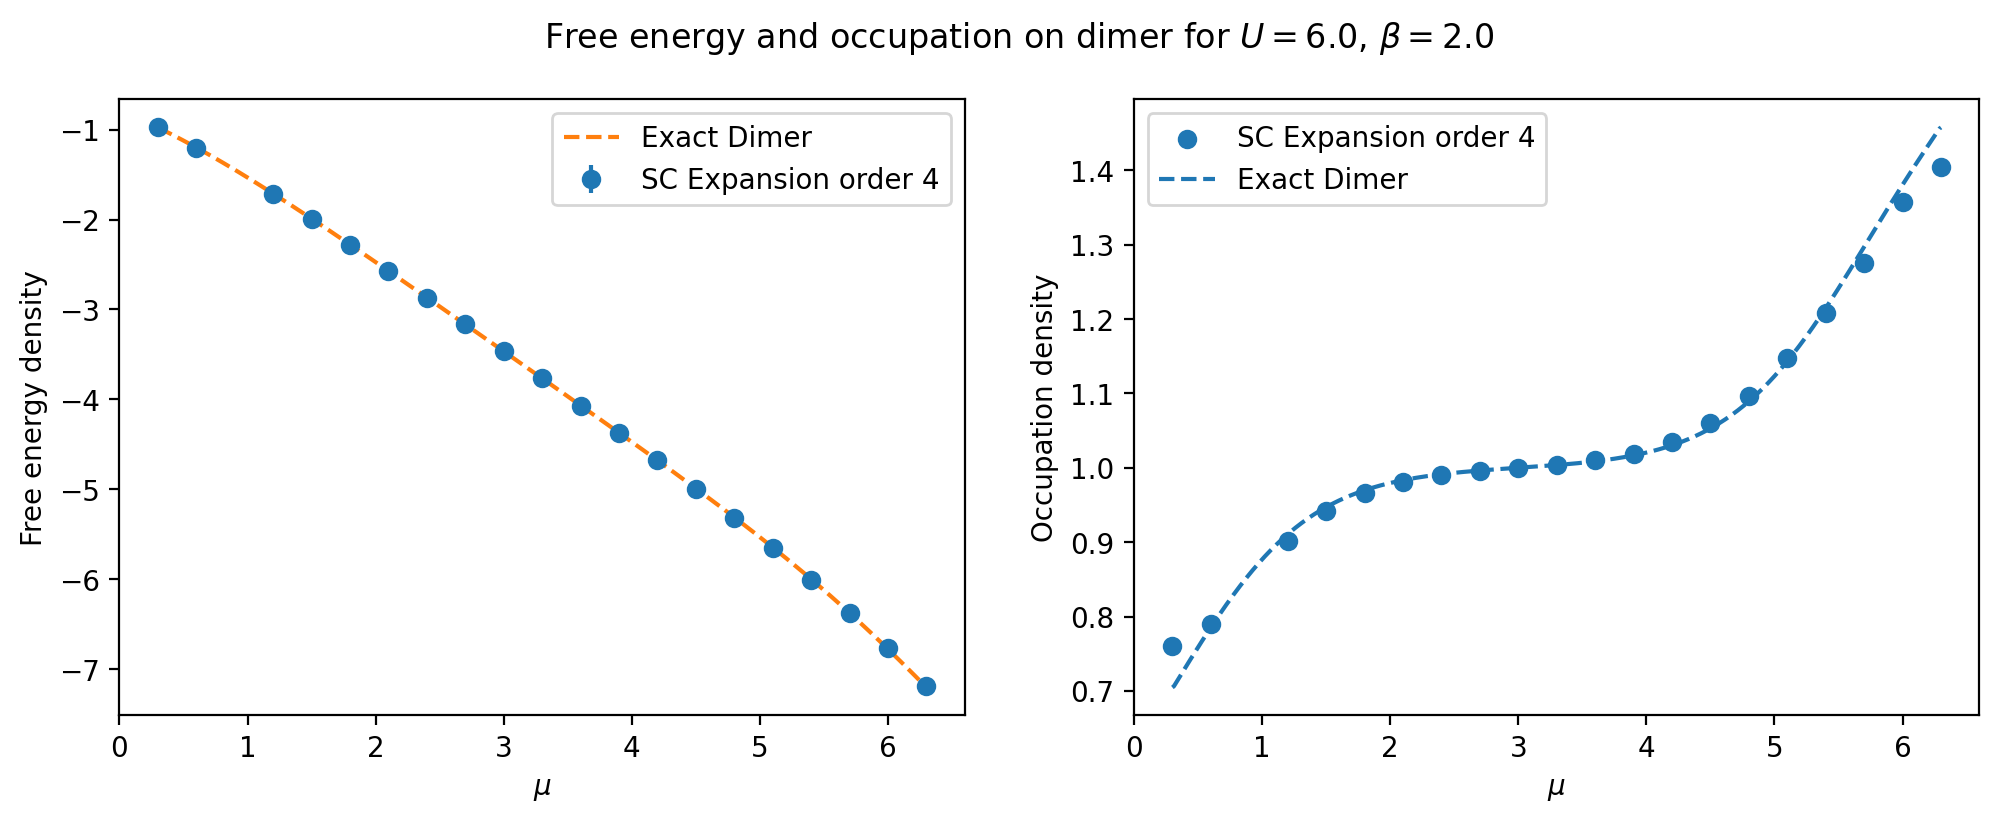

In [7]:

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,4))
fig.suptitle(rf"Free energy and occupation on dimer for $U={U}$, $\beta={beta}$")
ax1.errorbar(mus, lnZvals, yerr = errors, label='SC Expansion order 4', fmt='o')
ax1.plot(mus_fine, lnZexact, label='Exact Dimer', linestyle='dashed')
ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel('Free energy density')
ax1.legend()

ax2.scatter(mus, nvals, label='SC Expansion order 4', marker='o')
ax2.plot(mus_fine, nexact, label='Exact Dimer', linestyle='dashed')
ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel('Occupation density')
ax2.legend()



## Infinite Lattice

In [21]:
U = 6.0
beta = 2.0

path = '/Users/louissharma/Desktop/results_sc/results/full_lattice_lnZ_mu_U=6.0_beta=2.0.h5'
with h5py.File(path, 'r') as f:
    mus = f['mu_list'][:]
    means = f['mean_list'][:]
    errors = f['error_list'][:]

a0s = -np.log(Z_atomic(U, beta, mus))*1/beta
a2s = -4*Omega2_exact(U, beta, mus)*1/beta
a4s = means*1/beta


In [22]:
a4s, errors

(array([6.31442104, 6.653546  , 6.49306065, 5.86387788, 4.89996857,
        3.80681767, 2.7839232 , 5.64727596, 4.80539846, 3.94717416,
        3.16701806, 2.53439789, 2.02583535, 1.64741422, 1.35565402,
        1.14699914, 0.99056001, 0.87626436, 0.79438762, 0.73109883,
        0.69013135, 0.6555834 , 0.63948874, 0.62309707, 0.61782078,
        0.61809065, 0.61812901, 0.62320421, 0.63729564, 0.65763415,
        0.69224789, 0.73258749, 0.78887934, 0.87457821, 0.98702276,
        1.13281703, 1.35148614, 1.64450985, 2.03068301, 2.53091349,
        3.18240939, 3.94473119, 4.82257588, 5.66380511, 6.33455464,
        6.64087707, 6.48843906, 5.85347823, 4.88795444, 3.80129877]),
 array([0.05489984, 0.02214669, 0.01620663, 0.01534524, 0.01438835,
        0.01330239, 0.01201494, 0.02799661, 0.02135008, 0.01687059,
        0.01420077, 0.01277884, 0.01239807, 0.00999331, 0.00897657,
        0.00825183, 0.00802387, 0.00775042, 0.00776611, 0.00744484,
        0.00766902, 0.00762066, 0.0079019 , 0.

In [26]:
t=1.0
lnZ_full_lattice = -a0s -( a2s*t**2 + a4s*t**4)
n_full_lattice = np.gradient(-lnZ_full_lattice, mus)

lnZ_full_lattice_padé = (a0s + (a2s-a0s*a4s/a2s)*t**2)/(1-a4s/a2s*t**2)


n0s = np.gradient(-a0s, mus)
n2s = np.gradient(-(a2s), mus) 
n4s = np.gradient(-(a4s), mus)



n_full_lattice = np.gradient(lnZ_full_lattice, mus)

n_full_lattice_padé = (n0s + (n2s - n0s*a4s/a2s)*t**2)/(1 - a4s/a2s*t**2)

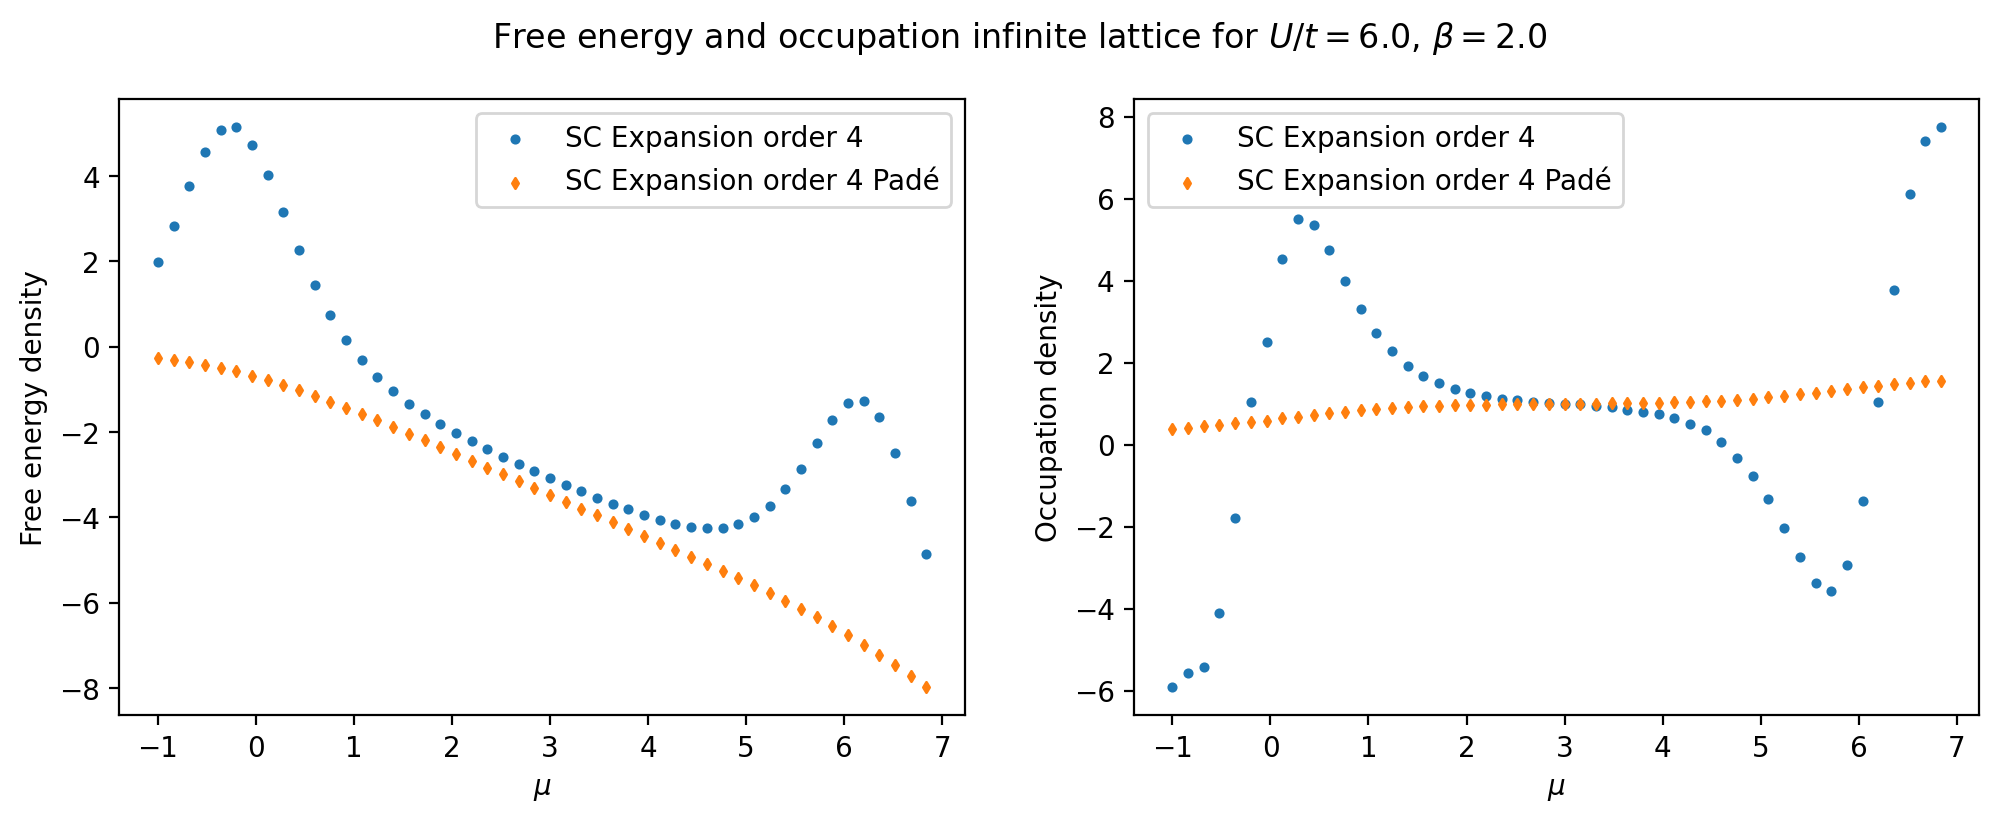

In [27]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,4))

fig.suptitle(rf"Free energy and occupation infinite lattice for $U/t={U/t}$, $\beta={beta}$")


ax1.scatter(mus, -lnZ_full_lattice, label='SC Expansion order 4', marker='o', s=7)
ax1.scatter(mus, lnZ_full_lattice_padé, label='SC Expansion order 4 Padé', marker='d', s=7)


ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel('Free energy density')
ax1.legend()

ax2.scatter(mus, n_full_lattice, label='SC Expansion order 4', marker='o', s=7)
ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel('Occupation density')
ax2.scatter(mus, n_full_lattice_padé, label='SC Expansion order 4 Padé', marker='d', s=7)
ax2.legend()


In [28]:
n0s = np.gradient(a0s, mus)
n2s = np.gradient(a2s, mus)
n4s = np.gradient(a4s, mus)

t=1.0

def pade_on_mu(coeffs, order, t,tol=0.0):
    res = pade_approx(coeffs, order, tol)
    return res[0](t).real


results_n_mu = {(2,2): [], (3,1): [], (1,3): []}
results_F_mu = {(2,2): [], (3,1): [], (1,3): []}

for idx, mu in enumerate(mus):
    coeffs_n = [n0s[idx], 0.0, n2s[idx], 0.0, n4s[idx]]
    coeffs_F = [a0s[idx], 0.0, a2s[idx], 0.0, a4s[idx]]
    # for order in results_n_mu.keys():
    #     res = pade_on_mu(coeffs_n, order)
    #     results_n_mu[order].append(res)
    for order in results_F_mu.keys():
        res = pade_on_mu(coeffs_F, order,t)
        results_F_mu[order].append(res)


naive_sum_F_mu = (a0s + a2s*t**2 + a4s*t**4)
naive_sum_n_mu = -(n0s + n2s*t**2 + n4s*t**4)

In [29]:
len(n0s), len(a0s)

(50, 50)

(0.0, 2.0)

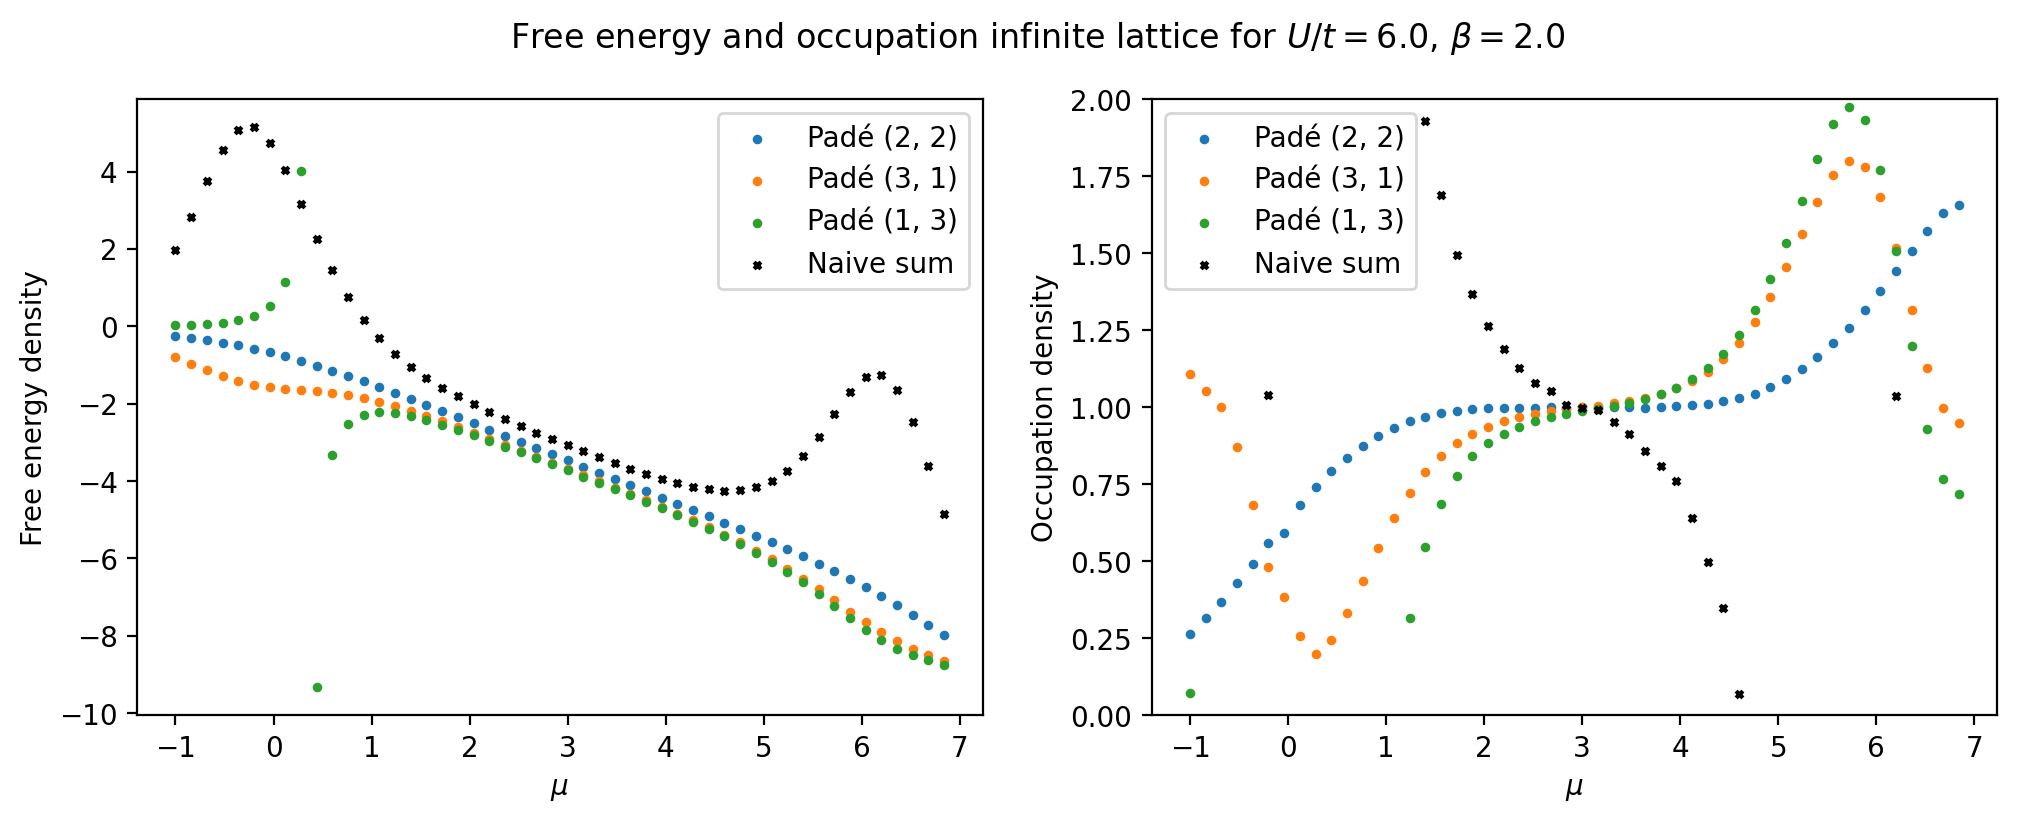

In [30]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,4))

fig.suptitle(rf"Free energy and occupation infinite lattice for $U/t={U/t}$, $\beta={beta}$")


for order, F_mu in results_F_mu.items():
    ax1.scatter(mus, np.array(F_mu), label=f'Padé {order}', marker='o', s=6)

ax1.scatter(mus, naive_sum_F_mu, label='Naive sum', marker='x', s=6, color='black')
ax1.set_xlabel(r'$\mu$')
ax1.set_ylabel('Free energy density')
ax1.legend()

for order, F_mu in results_F_mu.items():
    ax2.scatter(mus, -np.gradient(np.array(F_mu), mus), label=f'Padé {order}', marker='o', s=6)

ax2.scatter(mus, naive_sum_n_mu, label='Naive sum', marker='x', s=6, color='black')
ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel('Occupation density')
ax2.legend()
ax2.set_ylim(0,2)

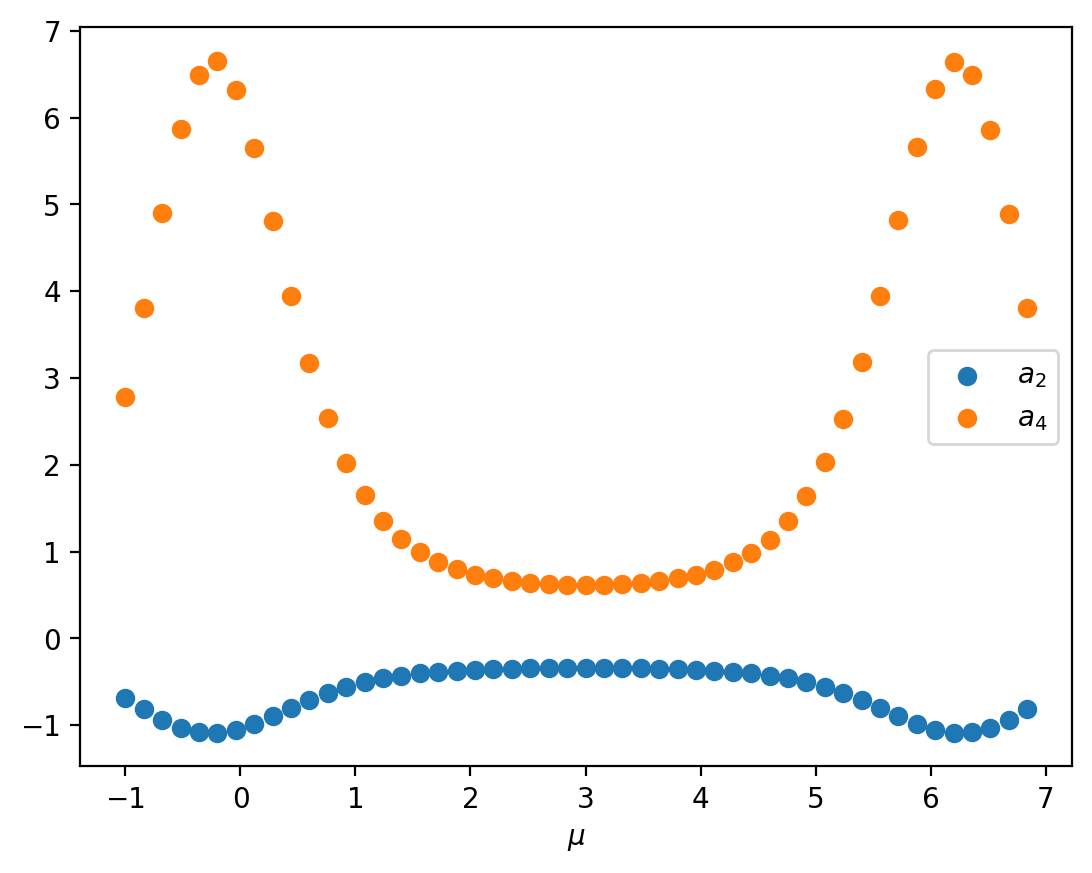

In [31]:
plt.scatter(mus, a2s, label = '$a_2$')
plt.scatter(mus, a4s, label = '$a_4$')
plt.xlabel(r'$\mu$')
plt.legend()

In [32]:
mus_fine=np.linspace(-U,U,500)
n_atom = -np.gradient(-1/beta*np.log(Z_atomic(U, beta, mus_fine)), mus_fine)

In [ ]:
plt.plot(mus_fine, n_atom, label='Atomic limit', linestyle='dashed')

In [ ]:
np.min(errors/means), np.max(errors/means)